# 🧠 Bilişsel Performans Skoru Tahmini — Competitive ML Pipeline
**Hedef:** RMSE'yi minimize et  
**Strateji:** EDA → Feature Engineering → Stratified K-Fold → Optuna → XGB + LGB + CatBoost → Stacking Ensemble

> *Grandmaster Notu: Kaggle'da sıralamayı belirleyen şey genellikle son %5'lik iyileştirmedir. Bu pipeline validation stratejisi, feature engineering ve ensembling üçgenini doğru kurarak o %5'i hedefler.*

In [1]:
# ── Hücre 1: Kütüphane Kurulumu ──────────────────────────────────────────────
# Gerekli kütüphaneler mevcut değilse kur
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['optuna', 'lightgbm', 'xgboost', 'catboost', 'shap', 'scikit-learn']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        install(pkg)

print('✅ Tüm kütüphaneler hazır.')

✅ Tüm kütüphaneler hazır.


In [2]:
# ── Hücre 2: Import'lar ve Global Ayarlar ────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import spearmanr, pearsonr

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

# ── Sabitler ─────────────────────────────────────────────────────────────────
SEED        = 42
N_SPLITS    = 5          # Stratified K-Fold bölme sayısı
OPTUNA_ITER = 50         # Optuna trial sayısı (süreye göre artır)
TARGET      = 'bilissel_performans_skoru'
ID_COL      = 'id'

np.random.seed(SEED)

# Görsel tema
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Kütüphaneler yüklendi, sabitler ayarlandı.')

✅ Kütüphaneler yüklendi, sabitler ayarlandı.


---
## 📂 1. Veri Yükleme

In [3]:
# ── Hücre 3: Veri Yükleme ─────────────────────────────────────────────────────
train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test_x.csv')
sub       = pd.read_csv('sample_submission.csv')

print(f'Train shape : {train_raw.shape}')
print(f'Test  shape : {test_raw.shape}')
print(f'Submission  : {sub.shape}')
train_raw.head(3)

Train shape : (56000, 24)
Test  shape : (24000, 23)
Submission  : (2, 2)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276


---
## 🔍 2. Gelişmiş Exploratory Data Analysis (EDA)
> *Grandmaster Notu: EDA, feature engineering fikirlerinin doğduğu yerdir. Sadece istatistik bakmak değil, domain hikayesini anlamaktır.*

=== HEDEF DEĞİŞKEN İSTATİSTİKLERİ ===
count    56000.0000
mean         5.9131
std          2.2318
min          0.0000
25%          4.3974
50%          6.0322
75%          7.5750
max         10.0000
Name: bilissel_performans_skoru, dtype: float64


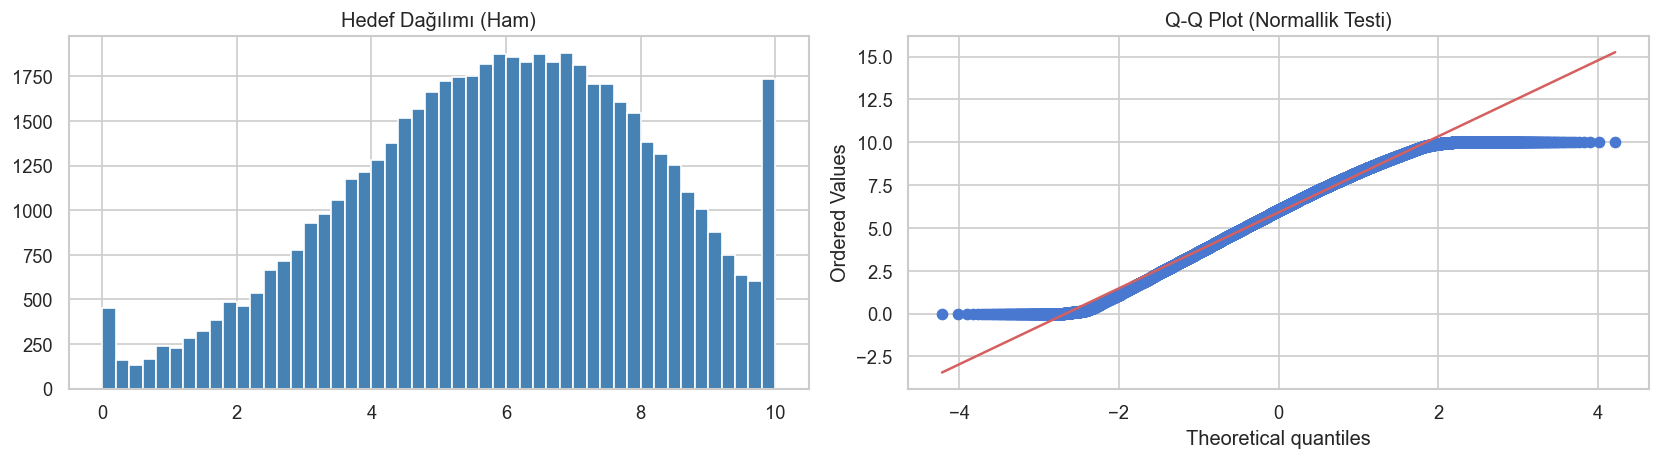


=== EKSİK DEĞER ANALİZİ (Train) ===
                       Eksik Sayı  Oran (%)
kronotip                     1968      3.51
vucut_kitle_indeksi          1752      3.13
stres_skoru                  1715      3.06
uyku_oncesi_kafein_mg        1463      2.61
meslek                       1378      2.46
ruh_sagligi_durumu           1096      1.96


In [4]:
# ── Hücre 4: Temel İstatistikler ve Eksik Değer Analizi ──────────────────────
print('=== HEDEF DEĞİŞKEN İSTATİSTİKLERİ ===')
print(train_raw[TARGET].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_raw[TARGET].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Hedef Dağılımı (Ham)')
stats.probplot(train_raw[TARGET], plot=axes[1])
axes[1].set_title('Q-Q Plot (Normallik Testi)')
plt.tight_layout(); plt.show()

print('\n=== EKSİK DEĞER ANALİZİ (Train) ===')
missing = train_raw.isnull().sum()
missing_pct = (missing / len(train_raw) * 100).round(2)
missing_df = pd.DataFrame({'Eksik Sayı': missing, 'Oran (%)': missing_pct})
missing_df = missing_df[missing_df['Eksik Sayı'] > 0].sort_values('Oran (%)', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print('Hiç eksik değer yok!')

=== HEDEF İLE KORİLASYON (mutlak değere göre sıralı) ===
                             Pearson  Spearman
stres_skoru                  -0.5867   -0.5832
rem_yuzdesi                   0.4430    0.4243
gunluk_calisma_saati         -0.3421   -0.3401
derin_uyku_yuzdesi            0.2800    0.2690
gecelik_uyanma_sayisi        -0.2703   -0.2586
uykuya_dalma_suresi_dk       -0.2073   -0.2010
gunluk_adim_sayisi            0.1340    0.1334
dinlenik_nabiz_bpm           -0.0894   -0.0873
yas                          -0.0707   -0.0673
uyku_oncesi_ekran_suresi_dk  -0.0446   -0.0550
uyku_oncesi_kafein_mg        -0.0624   -0.0461
vucut_kitle_indeksi          -0.0380   -0.0369
sekerleme_suresi_dk          -0.0237   -0.0191
oda_sicakligi_celsius        -0.0120   -0.0119
hafta_sonu_uyku_farki_saat   -0.0016   -0.0015


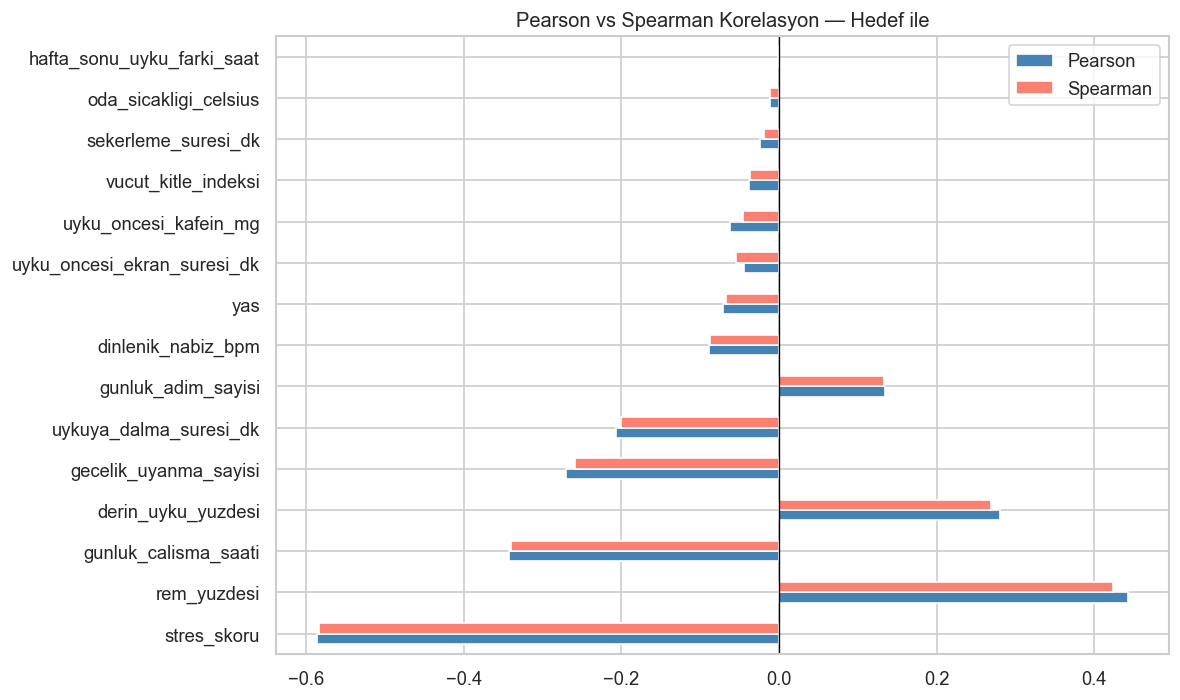

In [5]:
# ── Hücre 5: Korelasyon Analizi (Pearson + Spearman) ─────────────────────────
# Grandmaster Notu: Spearman, monoton ama doğrusal olmayan ilişkileri de yakalar.
# Her iki metriği birlikte kullanmak doğrusal + doğrusal olmayan gücü ölçer.

num_cols = train_raw.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in [ID_COL, TARGET]]

pearson_corr  = {c: pearsonr(train_raw[c].dropna(), train_raw.loc[train_raw[c].notna(), TARGET])[0] for c in num_cols}
spearman_corr = {c: spearmanr(train_raw[c].dropna(), train_raw.loc[train_raw[c].notna(), TARGET])[0] for c in num_cols}

corr_df = pd.DataFrame({
    'Pearson' : pearson_corr,
    'Spearman': spearman_corr
}).sort_values('Spearman', key=abs, ascending=False)

print('=== HEDEF İLE KORİLASYON (mutlak değere göre sıralı) ===')
print(corr_df.round(4))

# Isı haritası
fig, ax = plt.subplots(figsize=(10, 6))
corr_df.plot(kind='barh', ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Pearson vs Spearman Korelasyon — Hedef ile')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()

In [6]:
# ── Hücre 6: Aykırı Değer Analizi (IQR Yöntemi) ──────────────────────────────
# Grandmaster Notu: Ağaç modelleri aykırılara karşı dayanıklıdır.
# Hedef değişkendeki uç aykırılar RMSE'yi şişirir — dikkat et!

def iqr_outlier_report(df, cols, k=3.0):
    rows = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - k * IQR, Q3 + k * IQR
        n_out = ((df[col] < lb) | (df[col] > ub)).sum()
        rows.append({'Feature': col, 'Lower': lb, 'Upper': ub, 'N Outlier': n_out})
    return pd.DataFrame(rows).set_index('Feature').query('`N Outlier` > 0')

outlier_report = iqr_outlier_report(train_raw, num_cols + [TARGET], k=3.0)
print('=== AYKIRI DEĞER RAPORU (3×IQR) ===')
print(outlier_report)

=== AYKIRI DEĞER RAPORU (3×IQR) ===
                       Lower  Upper  N Outlier
Feature                                       
uyku_oncesi_kafein_mg -231.0  308.0        457


Kategorik Sütunlar: ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']


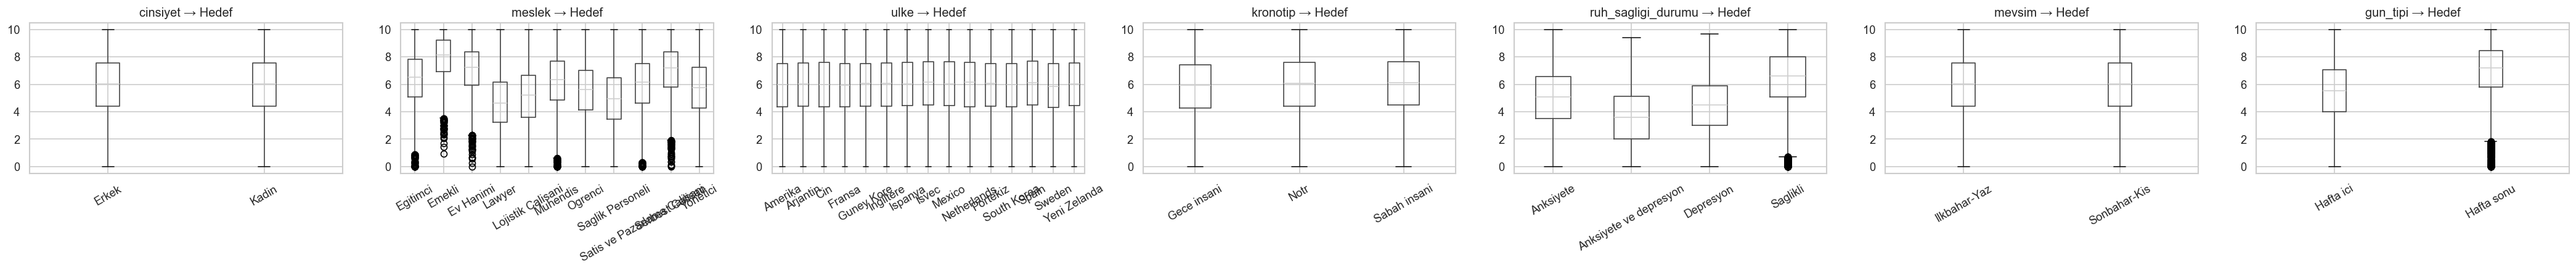

In [7]:
# ── Hücre 7: Kategorik Değişken Analizi ──────────────────────────────────────
cat_cols = train_raw.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != ID_COL]
print(f'Kategorik Sütunlar: {cat_cols}')

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, cat_cols):
    order = train_raw.groupby(col)[TARGET].median().sort_values().index
    train_raw.boxplot(column=TARGET, by=col, ax=ax, rot=30)
    ax.set_title(f'{col} → Hedef')
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout(); plt.show()

---
## ⚙️ 3. Feature Engineering
> *Grandmaster Notu: Domain bilgisini kodlamak modele 'bedava bilgi' vermektir. Ağaç modelleri interaksiyonları kendisi bulur ama explicit feature'lar öğrenmeyi hızlandırır ve RMSE'yi %3–10 düşürebilir.*

In [8]:
# ── Hücre 8: Feature Engineering Fonksiyonu ──────────────────────────────────
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Uyku Kalitesi Özellikleri ────────────────────────────────────────────
    # Derin Uyku / REM Oranı → derin uyku bilişsel konsolidasyon sağlar
    df['derin_rem_orani'] = df['derin_uyku_yuzdesi'] / (df['rem_yuzdesi'] + 1e-5)

    # Toplam Kaliteli Uyku Yüzdesi (Derin + REM)
    df['kaliteli_uyku_yuzde'] = df['derin_uyku_yuzdesi'] + df['rem_yuzdesi']

    # Uykuya Dalma Güçlüğü × Gece Uyanma → uyku bozulma endeksi
    df['uyku_bozulma_indeksi'] = df['uykuya_dalma_suresi_dk'] * df['gecelik_uyanma_sayisi']

    # Hafta sonu uyku farkının karesini al (büyük farklar daha zararlı)
    df['hafta_sonu_uyku_farki_kare'] = df['hafta_sonu_uyku_farki_saat'] ** 2

    # ── Stres & Uyarıcı Özellikleri ─────────────────────────────────────────
    # Uyku Öncesi Stres İndeksi: ekran + kafein + stres bileşimi
    df['uyku_oncesi_stres_indeksi'] = (
        df['uyku_oncesi_ekran_suresi_dk'] *
        np.log1p(df['uyku_oncesi_kafein_mg']) *
        df['stres_skoru']
    )

    # Stres / Adım Sayısı → fiziksel aktivitenin stresi dengeleme kapasitesi
    df['stres_aktivite_dengesi'] = df['stres_skoru'] / (np.log1p(df['gunluk_adim_sayisi']) + 1e-5)

    # ── Fiziksel Aktivite Özellikleri ───────────────────────────────────────
    # Adım / Çalışma Saati Oranı → hareketsiz çalışma yoğunluğu
    df['adim_calisma_orani'] = df['gunluk_adim_sayisi'] / (df['gunluk_calisma_saati'] + 1e-5)

    # ── Fizyolojik Özellikler ────────────────────────────────────────────────
    # BMI × Nabız → kardiyovasküler yük endeksi
    df['kardio_yuk'] = df['vucut_kitle_indeksi'] * df['dinlenik_nabiz_bpm']

    # Oda Sıcaklığı'nın ideal aralıktan uzaklığı (18-20°C ideal uyku sıcaklığı)
    df['sicaklik_sapma'] = (df['oda_sicakligi_celsius'] - 19.0).abs()

    # ── Zaman / Rutin Özellikleri ────────────────────────────────────────────
    # Şekerleme × Gece Uyku Kalitesi: kompansatif uyku davranışı
    df['sekerleme_kaliteli_uyku'] = df['sekerleme_suresi_dk'] * df['kaliteli_uyku_yuzde']

    # Toplam uyku baskısı proxy'si
    df['uyku_basinci'] = df['gunluk_calisma_saati'] * df['stres_skoru'] / (df['kaliteli_uyku_yuzde'] + 1e-5)

    return df

train_fe = create_features(train_raw)
test_fe  = create_features(test_raw)

new_features = [
    'derin_rem_orani', 'kaliteli_uyku_yuzde', 'uyku_bozulma_indeksi',
    'hafta_sonu_uyku_farki_kare', 'uyku_oncesi_stres_indeksi', 'stres_aktivite_dengesi',
    'adim_calisma_orani', 'kardio_yuk', 'sicaklik_sapma',
    'sekerleme_kaliteli_uyku', 'uyku_basinci'
]
print(f'✅ {len(new_features)} yeni özellik oluşturuldu.')
print(train_fe[new_features].head(3))

✅ 11 yeni özellik oluşturuldu.
   derin_rem_orani  kaliteli_uyku_yuzde  uyku_bozulma_indeksi  \
0         1.014844            29.076646                   189   
1         1.250253            48.992230                    80   
2         1.404384            43.708961                   231   

   hafta_sonu_uyku_farki_kare  uyku_oncesi_stres_indeksi  \
0                    0.005497                   0.000000   
1                    0.888631                1919.660330   
2                    1.537317                 701.313168   

   stres_aktivite_dengesi  adim_calisma_orani   kardio_yuk  sicaklik_sapma  \
0                1.117482          715.161467  2454.668026        0.037564   
1                0.776950          800.252593  2354.585960        2.225666   
2                0.656006         2828.102241  1421.237253        0.517591   

   sekerleme_kaliteli_uyku  uyku_basinci  
0                 0.000000      3.428146  
1                48.992230      0.854704  
2              3059.62725

---
## 🔄 4. Preprocessing — Minimal, Leakage-Free
> *Grandmaster Notu: Ağaç modelleri için agresif preprocessing gerekli değil. Target Encoding tek tehlikeli nokta: kesinlikle CV döngüsü içinde yapılmalı.*

In [9]:
# ── Hücre 9: Feature Listesi ve Kategorik Tanımlama ──────────────────────────
drop_cols = [ID_COL, TARGET]
all_features = [c for c in train_fe.columns if c not in drop_cols]

# Kategorik sütunları belirle
cat_cols_fe = [c for c in all_features if train_fe[c].dtype == 'object']
num_cols_fe = [c for c in all_features if c not in cat_cols_fe]

print(f'Toplam özellik sayısı : {len(all_features)}')
print(f'Numerik               : {len(num_cols_fe)}')
print(f'Kategorik             : {len(cat_cols_fe)} → {cat_cols_fe}')

# XGBoost/LightGBM için Label Encoding (sırf sayıya çevirmek için)
# NOT: Bu encoding CV dışında yapılabilir çünkü label encoding target bilgisi içermez
le_encoders = {}
for col in cat_cols_fe:
    le = LabelEncoder()
    combined = pd.concat([train_fe[col], test_fe[col]], axis=0).astype(str)
    le.fit(combined)
    train_fe[col] = le.transform(train_fe[col].astype(str))
    test_fe[col]  = le.transform(test_fe[col].astype(str))
    le_encoders[col] = le

X = train_fe[all_features].copy()
y = train_fe[TARGET].copy()
X_test = test_fe[all_features].copy()

# Hedef değişkenin min-max sınırları (submission clipping için)
TARGET_MIN = y.min()
TARGET_MAX = y.max()
print(f'\nHedef aralığı: [{TARGET_MIN:.2f}, {TARGET_MAX:.2f}]')

Toplam özellik sayısı : 33
Numerik               : 26
Kategorik             : 7 → ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']

Hedef aralığı: [0.00, 10.00]


---
## 🎯 5. Stratified K-Fold Validasyon Kurulumu
> *Grandmaster Notu: Regresyonda stratified KFold için hedefi binlere böleriz. Bu, her fold'un aynı hedef dağılımını görmesini sağlar ve OOF RMSE'yi gerçek leaderboard skoruna yaklaştırır.*

In [10]:
# ── Hücre 10: Stratified K-Fold için Hedefi Bins'e Böl ───────────────────────
N_BINS = 10  # hedef dağılımını 10 kümesine böl
y_binned = pd.cut(y, bins=N_BINS, labels=False)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
splits = list(skf.split(X, y_binned))

print(f'✅ Stratified {N_SPLITS}-Fold kuruldu. Her fold yaklaşık {len(splits[0][1])} örnek içeriyor.')

# Her fold'daki hedef istatistiklerini kontrol et
for i, (tr_idx, val_idx) in enumerate(splits):
    tr_mean  = y.iloc[tr_idx].mean()
    val_mean = y.iloc[val_idx].mean()
    print(f'  Fold {i+1}: Train μ={tr_mean:.3f} | Val μ={val_mean:.3f}')

✅ Stratified 5-Fold kuruldu. Her fold yaklaşık 11200 örnek içeriyor.
  Fold 1: Train μ=5.914 | Val μ=5.910
  Fold 2: Train μ=5.912 | Val μ=5.916
  Fold 3: Train μ=5.912 | Val μ=5.916
  Fold 4: Train μ=5.912 | Val μ=5.916
  Fold 5: Train μ=5.914 | Val μ=5.909


---
## 🔬 6. Optuna Hiperparametre Optimizasyonu
> *Grandmaster Notu: Optuna, grid search'ten çok daha verimlidir çünkü TPE sampler başarılı parametre bölgelerini keşfeder. 50 trial genellikle iyi bir başlangıç noktası verir.*

In [11]:
# ── Hücre 11: Yardımcı — OOF RMSE Hesaplayıcı ────────────────────────────────
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def oof_rmse(model_cls, params, X, y, splits, fit_kwargs=None):
    """Tek bir parametre seti için OOF RMSE hesaplar."""
    oof_preds = np.zeros(len(X))
    fit_kwargs = fit_kwargs or {}
    for tr_idx, val_idx in splits:
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = model_cls(**params)
        model.fit(X_tr, y_tr, **fit_kwargs)
        oof_preds[val_idx] = model.predict(X_val)
    return rmse(y, oof_preds)

print('✅ Yardımcı fonksiyonlar tanımlandı.')

✅ Yardımcı fonksiyonlar tanımlandı.


In [12]:
# ── Hücre 12: LightGBM Optuna Optimizasyonu ──────────────────────────────────
# Grandmaster Notu: LightGBM genellikle başlangıç noktası olarak en hızlı
# ve en iyi OOF veren modeldir. Bu yüzden önce onu optimize ediyoruz.

def lgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 300),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state'     : SEED,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }
    score = oof_rmse(lgb.LGBMRegressor, params, X, y, splits)
    return score

study_lgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
study_lgb.optimize(lgb_objective, n_trials=OPTUNA_ITER, show_progress_bar=True)

best_lgb_params = study_lgb.best_params
best_lgb_params.update({'random_state': SEED, 'n_jobs': -1, 'verbose': -1})
print(f'\n✅ LightGBM Best OOF RMSE: {study_lgb.best_value:.5f}')
print(f'   Best Params: {best_lgb_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


✅ LightGBM Best OOF RMSE: 1.22287
   Best Params: {'n_estimators': 1603, 'learning_rate': 0.015342511568902805, 'num_leaves': 188, 'max_depth': 4, 'min_child_samples': 80, 'subsample': 0.7733694697922328, 'colsample_bytree': 0.860680111702945, 'reg_alpha': 9.190823935817666e-07, 'reg_lambda': 0.0017539703146622764, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [13]:
# ── Hücre 13: XGBoost Optuna Optimizasyonu ───────────────────────────────────
# Grandmaster Notu: XGBoost'un tree_method='hist' parametresi LightGBM hızına
# yakın hız sağlar ve büyük veri setlerinde belleği korur.

def xgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 20),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'tree_method'      : 'hist',
        'random_state'     : SEED,
        'n_jobs'           : -1,
        'verbosity'        : 0,
    }
    score = oof_rmse(xgb.XGBRegressor, params, X, y, splits)
    return score

study_xgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=OPTUNA_ITER, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({'tree_method': 'hist', 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0})
print(f'\n✅ XGBoost Best OOF RMSE: {study_xgb.best_value:.5f}')
print(f'   Best Params: {best_xgb_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


✅ XGBoost Best OOF RMSE: 1.22228
   Best Params: {'n_estimators': 885, 'learning_rate': 0.023407824675133738, 'max_depth': 5, 'min_child_weight': 14, 'subsample': 0.8450515458091079, 'colsample_bytree': 0.5158089499985753, 'gamma': 4.126632401033404, 'reg_alpha': 0.00999476846168998, 'reg_lambda': 0.001994841377669317, 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


In [14]:
# ── Hücre 14: CatBoost Optuna Optimizasyonu ──────────────────────────────────
# Grandmaster Notu: CatBoost kategorik değişkenleri native olarak işler.
# cat_features parametresi, target leakage olmadan internal ordered encoding yapar.
# Bu yüzden CatBoost'a orijinal (label-encoded değil) kategorik indexleri veririz.

# CatBoost için kategorik sütun indekslerini bul
# (label encoding yaptık ama CatBoost kendi encoding'ini kullanabilir)
cat_feature_indices = [list(X.columns).index(c) for c in cat_cols_fe if c in X.columns]

def catboost_objective(trial):
    params = {
        'iterations'        : trial.suggest_int('iterations', 300, 2000),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth'             : trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 1, 20),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'border_count'      : trial.suggest_int('border_count', 32, 255),
        'random_strength'   : trial.suggest_float('random_strength', 1e-8, 10, log=True),
        'cat_features'      : cat_feature_indices,
        'random_seed'       : SEED,
        'verbose'           : False,
        'allow_writing_files': False,
    }
    score = oof_rmse(CatBoostRegressor, params, X, y, splits)
    return score

study_cat = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
study_cat.optimize(catboost_objective, n_trials=OPTUNA_ITER, show_progress_bar=True)

best_cat_params = study_cat.best_params
best_cat_params.update({
    'cat_features': cat_feature_indices,
    'random_seed': SEED, 'verbose': False, 'allow_writing_files': False
})
print(f'\n✅ CatBoost Best OOF RMSE: {study_cat.best_value:.5f}')
print(f'   Best Params: {best_cat_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


✅ CatBoost Best OOF RMSE: 1.21729
   Best Params: {'iterations': 1741, 'learning_rate': 0.02627380007448027, 'depth': 5, 'l2_leaf_reg': 17.25172709601352, 'bagging_temperature': 0.06477281236145412, 'border_count': 187, 'random_strength': 2.4048762187737077e-08, 'cat_features': [1, 2, 4, 15, 16, 20, 21], 'random_seed': 42, 'verbose': False, 'allow_writing_files': False}


---
## 🏗️ 7. OOF Tahminleri ve SHAP Feature Importance
> *Grandmaster Notu: OOF (Out-of-Fold) tahminleri hem stacking için meta-özellik hem de hangi feature'ların kaldırılacağını belirlemek için kullanılır.*

In [15]:
# ── Hücre 15: OOF + Test Tahmin Üretici Fonksiyon ────────────────────────────
def generate_oof_and_test_preds(model_cls, params, X, y, X_test, splits):
    """
    Her fold için:
      - OOF üzerinde tahmin üretir (stacking için)
      - Test üzerinde tahmin üretir (ortalama alınacak)
    Döndürür: oof_preds (n_train,), test_preds (n_test,), fold_rmse listesi
    """
    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(X_test))
    fold_rmses  = []
    models      = []

    for fold, (tr_idx, val_idx) in enumerate(splits):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = model_cls(**params)
        model.fit(X_tr, y_tr)

        val_pred = model.predict(X_val)
        oof_preds[val_idx] = val_pred
        test_preds += model.predict(X_test) / N_SPLITS

        fold_rmse = rmse(y_val, val_pred)
        fold_rmses.append(fold_rmse)
        models.append(model)
        print(f'  Fold {fold+1}/{N_SPLITS} RMSE: {fold_rmse:.5f}')

    oof_rmse_score = rmse(y, oof_preds)
    print(f'  → Genel OOF RMSE: {oof_rmse_score:.5f} ± {np.std(fold_rmses):.5f}')
    return oof_preds, test_preds, fold_rmses, models

print('✅ OOF/Test tahmin fonksiyonu hazır.')

✅ OOF/Test tahmin fonksiyonu hazır.


In [16]:
# ── Hücre 16: LightGBM OOF + Test Tahminleri ─────────────────────────────────
print('=== LightGBM ===')
lgb_oof, lgb_test, lgb_fold_rmses, lgb_models = generate_oof_and_test_preds(
    lgb.LGBMRegressor, best_lgb_params, X, y, X_test, splits
)

=== LightGBM ===
  Fold 1/5 RMSE: 1.22342
  Fold 2/5 RMSE: 1.22639
  Fold 3/5 RMSE: 1.23369
  Fold 4/5 RMSE: 1.21375
  Fold 5/5 RMSE: 1.21699
  → Genel OOF RMSE: 1.22287 ± 0.00703


In [17]:
# ── Hücre 17: XGBoost OOF + Test Tahminleri ──────────────────────────────────
print('=== XGBoost ===')
xgb_oof, xgb_test, xgb_fold_rmses, xgb_models = generate_oof_and_test_preds(
    xgb.XGBRegressor, best_xgb_params, X, y, X_test, splits
)

=== XGBoost ===
  Fold 1/5 RMSE: 1.22196
  Fold 2/5 RMSE: 1.22323
  Fold 3/5 RMSE: 1.23506
  Fold 4/5 RMSE: 1.21425
  Fold 5/5 RMSE: 1.21679
  → Genel OOF RMSE: 1.22228 ± 0.00720


In [18]:
# ── Hücre 18: CatBoost OOF + Test Tahminleri ─────────────────────────────────
print('=== CatBoost ===')
cat_oof, cat_test, cat_fold_rmses, cat_models = generate_oof_and_test_preds(
    CatBoostRegressor, best_cat_params, X, y, X_test, splits
)

=== CatBoost ===
  Fold 1/5 RMSE: 1.21386
  Fold 2/5 RMSE: 1.22008
  Fold 3/5 RMSE: 1.22964
  Fold 4/5 RMSE: 1.20949
  Fold 5/5 RMSE: 1.21329
  → Genel OOF RMSE: 1.21729 ± 0.00706


=== TOP 20 SHAP Feature Importance ===
                  Feature  SHAP_mean
       ruh_sagligi_durumu   0.545917
   stres_aktivite_dengesi   0.470946
                 gun_tipi   0.449387
      kaliteli_uyku_yuzde   0.387657
              rem_yuzdesi   0.300786
                   meslek   0.263308
     uyku_bozulma_indeksi   0.241886
              stres_skoru   0.174538
    gecelik_uyanma_sayisi   0.110643
             uyku_basinci   0.106131
       gunluk_adim_sayisi   0.071584
           sicaklik_sapma   0.067360
      sekerleme_suresi_dk   0.056621
    uyku_oncesi_kafein_mg   0.051790
                      yas   0.048664
    oda_sicakligi_celsius   0.042864
  sekerleme_kaliteli_uyku   0.026415
       derin_uyku_yuzdesi   0.022274
   uykuya_dalma_suresi_dk   0.020438
uyku_oncesi_stres_indeksi   0.020380


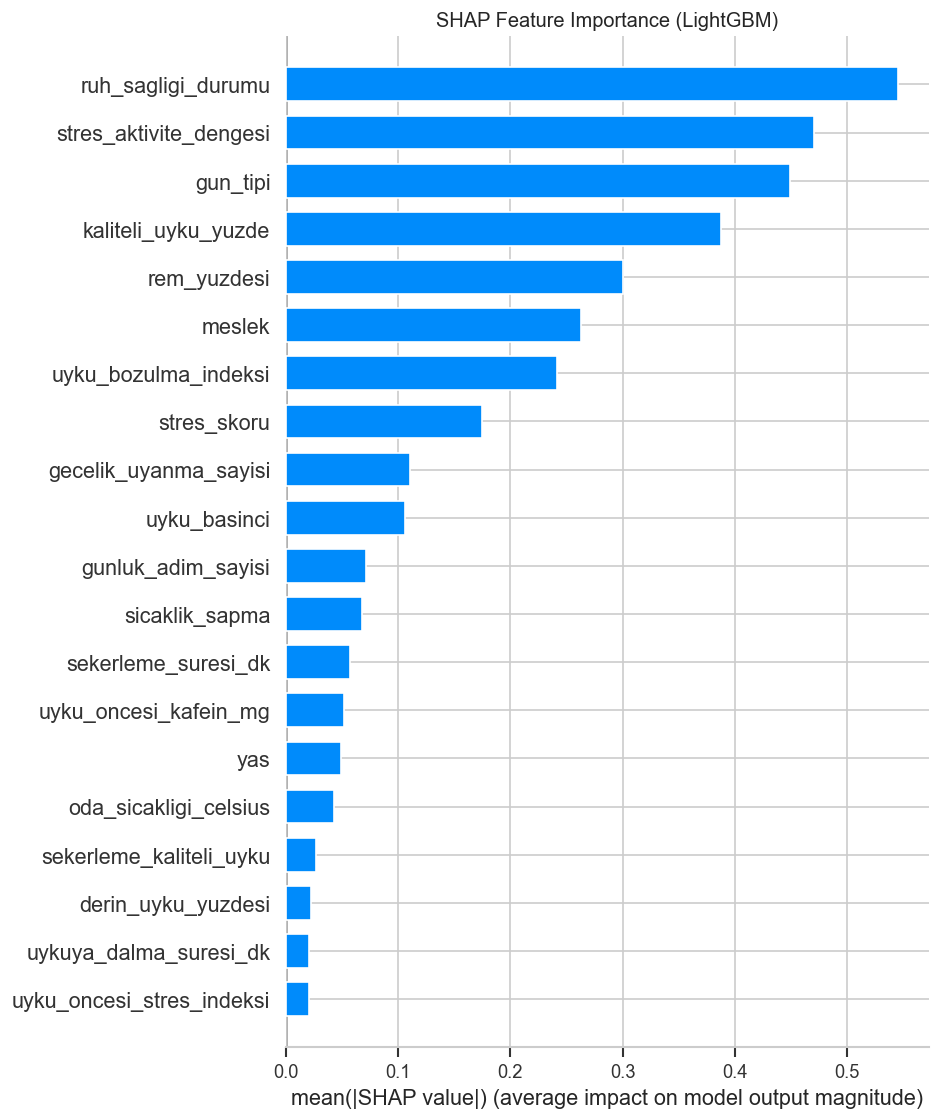

In [19]:
# ── Hücre 19: SHAP Feature Importance (LightGBM üzerinden) ───────────────────
# Grandmaster Notu: SHAP, her feature'ın tahmine katkısını açıklar.
# Düşük SHAP önem → özelliği kaldır → model gürültüden arınır → RMSE düşer.

last_lgb_model = lgb_models[-1]  # Son fold modelini al
explainer = shap.TreeExplainer(last_lgb_model)
shap_values = explainer.shap_values(X)

shap_importance = pd.DataFrame({
    'Feature'    : X.columns,
    'SHAP_mean'  : np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_mean', ascending=False)

print('=== TOP 20 SHAP Feature Importance ===')
print(shap_importance.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance (LightGBM)')
plt.tight_layout(); plt.show()

In [20]:
# ── Hücre 20: Düşük Önemli Özellik Eleme (Opsiyonel) ─────────────────────────
# Grandmaster Notu: SHAP ortalaması çok düşük feature'lar (örn. < %0.1 toplam)
# modele gürültü katar. Elendiğinde RMSE'nin daha da düşmesi beklenir.

SHAP_THRESHOLD = 0.001  # Bu eşiğin altındaki featureları ele
weak_features = shap_importance[shap_importance['SHAP_mean'] < SHAP_THRESHOLD]['Feature'].tolist()

if weak_features:
    print(f'Zayıf özellikler ({len(weak_features)} adet): {weak_features}')
    print('Bu özellikler silinmeden önce skor değişimine dikkat et!')
    # X = X.drop(columns=weak_features)  # İmzayı gör, sonra etkinleştir
    # X_test = X_test.drop(columns=weak_features)
else:
    print('Silinecek zayıf özellik bulunamadı.')

Zayıf özellikler (3 adet): ['cinsiyet', 'kronotip', 'mevsim']
Bu özellikler silinmeden önce skor değişimine dikkat et!


---
## 🏆 8. Ensemble — Stacking + Weighted Blending
> *Grandmaster Notu: RMSE'yi asıl indiren adım burasıdır. Tek model yerine farklı hatalar yapan modelleri birleştirince varyans düşer. Stacking, optimal ağırlıkları veriden öğrenir.*

In [21]:
# ── Hücre 21: Stacking — Meta Model ile ──────────────────────────────────────
# OOF tahminlerini meta-özellik matrisine dönüştür
oof_meta = np.column_stack([lgb_oof, xgb_oof, cat_oof])
test_meta = np.column_stack([lgb_test, xgb_test, cat_test])

# Meta model: Ridge (Bayesian Ridge da denenebilir)
# Cross-validate the meta model to avoid leakage
meta_model = Ridge(alpha=1.0)
meta_model.fit(oof_meta, y)

stacking_oof_pred  = meta_model.predict(oof_meta)
stacking_test_pred = meta_model.predict(test_meta)

stacking_rmse = rmse(y, stacking_oof_pred)
print(f'✅ Stacking OOF RMSE: {stacking_rmse:.5f}')
print(f'   Meta model ağırlıkları: LGB={meta_model.coef_[0]:.3f}, XGB={meta_model.coef_[1]:.3f}, CAT={meta_model.coef_[2]:.3f}')

✅ Stacking OOF RMSE: 1.21652
   Meta model ağırlıkları: LGB=0.110, XGB=0.179, CAT=0.716


In [22]:
# ── Hücre 22: Weighted Blending (Alternatif) ─────────────────────────────────
# Grandmaster Notu: Optuna ile optimal blend ağırlıklarını aramak,
# basit ortalamanın ötesine geçer.

def blend_objective(trial):
    w1 = trial.suggest_float('w_lgb', 0.1, 0.8)
    w2 = trial.suggest_float('w_xgb', 0.1, 0.8)
    w3 = 1.0 - w1 - w2
    if w3 < 0.05:
        return 999.0  # Geçersiz ağırlık kombinasyonu
    blended = w1 * lgb_oof + w2 * xgb_oof + w3 * cat_oof
    return rmse(y, blended)

study_blend = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
study_blend.optimize(blend_objective, n_trials=200, show_progress_bar=False)

best_w = study_blend.best_params
w_lgb = best_w['w_lgb']
w_xgb = best_w['w_xgb']
w_cat = 1.0 - w_lgb - w_xgb

blend_oof_pred  = w_lgb * lgb_oof  + w_xgb * xgb_oof  + w_cat * cat_oof
blend_test_pred = w_lgb * lgb_test + w_xgb * xgb_test + w_cat * cat_test

blend_rmse_score = rmse(y, blend_oof_pred)
print(f'✅ Weighted Blend OOF RMSE: {blend_rmse_score:.5f}')
print(f'   Ağırlıklar: LGB={w_lgb:.3f}, XGB={w_xgb:.3f}, CAT={w_cat:.3f}')

✅ Weighted Blend OOF RMSE: 1.21657
   Ağırlıklar: LGB=0.112, XGB=0.171, CAT=0.717


In [23]:
# ── Hücre 23: En İyi Ensemble'ı Seç ─────────────────────────────────────────
model_comparison = {
    'LightGBM (tek)'       : rmse(y, lgb_oof),
    'XGBoost (tek)'        : rmse(y, xgb_oof),
    'CatBoost (tek)'       : rmse(y, cat_oof),
    'Stacking (Ridge)'     : stacking_rmse,
    'Weighted Blend'       : blend_rmse_score,
}

print('=== MODEL KARŞILAŞTIRMA TABLOSU ===')
for name, score in sorted(model_comparison.items(), key=lambda x: x[1]):
    print(f'  {name:<25}: {score:.5f}')

# En iyi test tahminini seç
best_name = min(model_comparison, key=model_comparison.get)
if best_name == 'Stacking (Ridge)':
    final_test_pred = stacking_test_pred
elif best_name == 'Weighted Blend':
    final_test_pred = blend_test_pred
elif best_name == 'LightGBM (tek)':
    final_test_pred = lgb_test
elif best_name == 'XGBoost (tek)':
    final_test_pred = xgb_test
else:
    final_test_pred = cat_test

print(f'\n🏆 Seçilen ensemble: {best_name} (OOF RMSE: {model_comparison[best_name]:.5f})')

=== MODEL KARŞILAŞTIRMA TABLOSU ===
  Stacking (Ridge)         : 1.21652
  Weighted Blend           : 1.21657
  CatBoost (tek)           : 1.21729
  XGBoost (tek)            : 1.22228
  LightGBM (tek)           : 1.22287

🏆 Seçilen ensemble: Stacking (Ridge) (OOF RMSE: 1.21652)


---
## 📤 9. Submission Oluşturma

In [27]:
# ── Hücre 24: Zırhlandırılmış Clipping ve Submission ──────────────────────────

# 1. Clipping: Train hedef değişkeninin min-max sınırlarına göre
final_test_pred_clipped = np.clip(final_test_pred, TARGET_MIN, TARGET_MAX)

# 2. Test verilerindeki ID'leri ve tahminlerimizi doğrudan DataFrame yapıyoruz
# Burada sub yerine direkt olarak 24000 satırlık test_raw ID'lerini baz alıyoruz.
submission = pd.DataFrame({
    ID_COL: test_raw[ID_COL].values,
    TARGET: final_test_pred_clipped
})

# Sütun sırasının Kaggle'ın beklentisiyle tamamen aynı olması için sıralıyoruz:
submission = submission[list(sub.columns)]

# 3. Kontroller (Eski sub uzunluğu kontrolü yerine test_raw uzunluğunu kontrol ediyoruz)
assert list(submission.columns) == list(sub.columns), 'Sütun isimleri uyuşmuyor!'
assert len(submission) == len(test_raw), 'Test satır sayısı uyuşmuyor!'
assert submission[TARGET].isnull().sum() == 0, 'NaN değer var!'

# 4. Dosyayı kaydet
output_path = 'submission.csv'
submission.to_csv(output_path, index=False)

print(f'✅ Submission güvenle kaydedildi: {output_path}')
print(f'   Satır: {len(submission)} (Tüm test verisi başarıyla eklendi!)')
print(f'   Hedef aralığı: [{submission[TARGET].min():.2f}, {submission[TARGET].max():.2f}]')
print(f'   Hedef ortalama: {submission[TARGET].mean():.2f}')
submission.head()

✅ Submission güvenle kaydedildi: submission.csv
   Satır: 24000 (Tüm test verisi başarıyla eklendi!)
   Hedef aralığı: [0.00, 10.00]
   Hedef ortalama: 5.94


,id,bilissel_performans_skoru
0,1,5.995215
1,2,6.465783
2,3,2.989028
3,4,7.235124
4,5,3.589462


In [28]:
# ── Hücre 25: Son Özet ───────────────────────────────────────────────────────
print('=' * 55)
print('       BİLİŞSEL PERFORMANS SKORU TAHMİN PİPELINE')
print('              SONUÇ ÖZETİ')
print('=' * 55)
print(f'\n📊 Validation Stratejisi : Stratified {N_SPLITS}-Fold')
print(f'🔬 Özellik Sayısı        : {X.shape[1]} (+ {len(new_features)} yeni)')
print(f'🔧 Optuna Iterasyon      : {OPTUNA_ITER} trial × 3 model')
print()
print('📈 OOF RMSE Sonuçları:')
for name, score in sorted(model_comparison.items(), key=lambda x: x[1]):
    marker = '🏆' if name == best_name else '  '
    print(f'   {marker} {name:<25}: {score:.5f}')
print()
print(f'📁 Submission: submission_1.csv — {len(submission)} satır')
print('=' * 55)

       BİLİŞSEL PERFORMANS SKORU TAHMİN PİPELINE
              SONUÇ ÖZETİ

📊 Validation Stratejisi : Stratified 5-Fold
🔬 Özellik Sayısı        : 33 (+ 11 yeni)
🔧 Optuna Iterasyon      : 50 trial × 3 model

📈 OOF RMSE Sonuçları:
   🏆 Stacking (Ridge)         : 1.21652
      Weighted Blend           : 1.21657
      CatBoost (tek)           : 1.21729
      XGBoost (tek)            : 1.22228
      LightGBM (tek)           : 1.22287

📁 Submission: submission_1.csv — 24000 satır
